In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import sys
import os

# Add src to path so we can import our new tool
sys.path.append(os.path.abspath(".."))
from src.sentiment_analysis import get_sentiment_score

# Load the News Data (The Clean Version from Task 1)
print("Loading News Data... (This might take a moment)")
news_df = pd.read_csv("../data/processed/news_data_cleaned.csv")

# Convert Date just in case
news_df["date"] = pd.to_datetime(news_df["date"], errors="coerce", utc=True)

print(f"Loaded {len(news_df)} headlines.")
print(news_df.head(3))


Loading News Data... (This might take a moment)
Loaded 1407328 headlines.
   Unnamed: 0                                    headline  \
0           0     Stocks That Hit 52-Week Highs On Friday   
1           1  Stocks That Hit 52-Week Highs On Wednesday   
2           2               71 Biggest Movers From Friday   

                                                 url          publisher  \
0  https://www.benzinga.com/news/20/06/16190091/s...  Benzinga Insights   
1  https://www.benzinga.com/news/20/06/16170189/s...  Benzinga Insights   
2  https://www.benzinga.com/news/20/05/16103463/7...         Lisa Levin   

                       date stock  
0 2020-06-05 14:30:54+00:00     A  
1 2020-06-03 14:45:20+00:00     A  
2 2020-05-26 08:30:07+00:00     A  


In [ ]:
print("Starting Sentiment Analysis... Please wait.")

# We use .apply() to run our function on every row in the 'headline' column
# This creates a NEW column called 'sentiment'
news_df["sentiment"] = news_df["headline"].apply(get_sentiment_score)

print("--- Analysis Complete ---")
print(news_df[["date", "headline", "sentiment"]].head())

# Saved this so we never have to run it again
news_df.to_csv("../data/processed/news_with_sentiment.csv", index=False)


Starting Sentiment Analysis... Please wait.
--- Analysis Complete ---
                       date  \
0 2020-06-05 14:30:54+00:00   
1 2020-06-03 14:45:20+00:00   
2 2020-05-26 08:30:07+00:00   
3 2020-05-22 16:45:06+00:00   
4 2020-05-22 15:38:59+00:00   

                                            headline  sentiment  
0            Stocks That Hit 52-Week Highs On Friday      0.000  
1         Stocks That Hit 52-Week Highs On Wednesday      0.000  
2                      71 Biggest Movers From Friday      0.000  
3       46 Stocks Moving In Friday's Mid-Day Session      0.000  
4  B of A Securities Maintains Neutral on Agilent...      0.296  
Saved to '../data/processed/news_with_sentiment.csv'


In [13]:
# --- 1. Prepare News Data (Daily Aggregation) ---
# Load the data again to be clean
news_df = pd.read_csv("../data/processed/news_with_sentiment.csv")

In [14]:
# Convert to datetime
news_df["date"] = pd.to_datetime(news_df["date"])


In [15]:
# THE FIX: Remove Timezone info (.tz_localize(None)) AND normalize to midnight
news_df["date"] = news_df["date"].dt.tz_localize(None).dt.normalize()


In [17]:
# Now group by Date and Stock
daily_sentiment = news_df.groupby(["date", "stock"])["sentiment"].mean().reset_index()
print(f"Daily Sentiment Rows: {len(daily_sentiment)}")


Daily Sentiment Rows: 44204


In [19]:
# --- 2. Prepare Stock Data ---
stock_df = pd.read_csv("../data/processed/stock_prices_combined.csv")

# Convert to datetime
stock_df["date"] = pd.to_datetime(stock_df["date"])

# Ensure Stock data also has no timezone (Safety Check)
stock_df["date"] = stock_df["date"].dt.tz_localize(None).dt.normalize()
# Calculate Daily Returns
stock_df["daily_return"] = stock_df.groupby("stock")["close"].pct_change()


In [20]:
# --- 3. Merge the Worlds ---
# Now both 'date' columns are just plain dates (no UTC), so the merge will work
merged_df = pd.merge(daily_sentiment, stock_df, on=["date", "stock"], how="inner")

print(f"Final Merged Data Points: {len(merged_df)}")
print(merged_df[["date", "stock", "sentiment", "daily_return"]].head())


Final Merged Data Points: 13
        date stock  sentiment  daily_return
0 2020-06-02  NVDA   0.220200      0.002157
1 2020-06-04  GOOG   0.000000     -0.016848
2 2020-06-05  GOOG  -0.411033      0.018560
3 2020-06-08  GOOG   0.542300      0.005715
4 2020-06-08  NVDA   0.168667     -0.012892


Visualize the Correlation (The Heatmap)

--- Correlation Matrix ---
              sentiment  daily_return
sentiment      1.000000      0.170882
daily_return   0.170882      1.000000


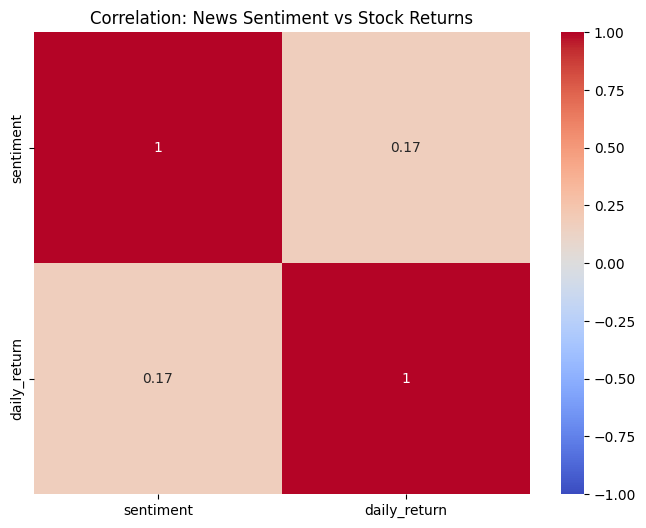

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Filter for numeric columns only
# We want to check correlation between:
# - Sentiment (How happy the news is)
# - Daily Return (How much the price jumped)
correlation_data = merged_df[["sentiment", "daily_return"]]

# 2. Calculate the Correlation Matrix
# This runs the math (Pearson Correlation)
corr_matrix = correlation_data.corr()

print("--- Correlation Matrix ---")
print(corr_matrix)

# 3. Plot the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation: News Sentiment vs Stock Returns")
plt.show()
